# SANITY CHECK

LOAD PACKAGES

In [2]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset

In [3]:
file_path = "data/Nubank_ads_data.csv"
df = pl.read_csv(file_path)

1. Check for missing values

In [4]:
missing_values = df.null_count()

In [5]:
print(f"There are {missing_values} \n missing values in the dataset")

There are shape: (1, 15)
┌─────────────┬────────────┬────────────┬────────────┬───┬────────┬────────────┬───────┬───────────┐
│ Reporting   ┆ Reporting  ┆ Campaign   ┆ Campaign   ┆ … ┆ Link   ┆ Conversion ┆ Reach ┆ Frequency │
│ Start       ┆ End        ┆ Name       ┆ Type       ┆   ┆ Clicks ┆ s          ┆ ---   ┆ ---       │
│ ---         ┆ ---        ┆ ---        ┆ ---        ┆   ┆ ---    ┆ ---        ┆ u32   ┆ u32       │
│ u32         ┆ u32        ┆ u32        ┆ u32        ┆   ┆ u32    ┆ u32        ┆       ┆           │
╞═════════════╪════════════╪════════════╪════════════╪═══╪════════╪════════════╪═══════╪═══════════╡
│ 0           ┆ 0          ┆ 0          ┆ 0          ┆ … ┆ 0      ┆ 0          ┆ 0     ┆ 0         │
└─────────────┴────────────┴────────────┴────────────┴───┴────────┴────────────┴───────┴───────────┘ 
 missing values in the dataset


2. Identify duplicate rows

In [6]:
duplicate_rows = df.is_duplicated().sum()

In [7]:
print(f"there are {duplicate_rows}")

there are 0


3. Check for negative values in numeric columns

In [8]:
numeric_columns = ["Spend (BRL)", "Impressions", "Link Clicks", "Conversions", "Reach", "Frequency"]
negative_values = {col: df.filter(pl.col(col) < 0).shape[0] for col in numeric_columns}

for i in negative_values:
  print(f"There is {negative_values[i]} negative values in the column '{i}' ")

There is 0 negative values in the column 'Spend (BRL)' 
There is 0 negative values in the column 'Impressions' 
There is 0 negative values in the column 'Link Clicks' 
There is 0 negative values in the column 'Conversions' 
There is 0 negative values in the column 'Reach' 
There is 0 negative values in the column 'Frequency' 


## Graphics Analysis

In [9]:
# Configuração para deixar os gráficos mais bonitos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# 1. Estatísticas descritivas (mantido igual)
descriptive_stats = df.select([
    "Spend (BRL)",
    "Impressions",
    "Link Clicks",
    "Conversions",
    "Reach",
    "Frequency"
]).describe()

descriptive_stats

statistic,Spend (BRL),Impressions,Link Clicks,Conversions,Reach,Frequency
str,f64,f64,f64,f64,f64,f64
"""count""",610.0,610.0,610.0,610.0,610.0,610.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",2081.357967,312052.793443,215.34918,13.25082,233914.27377,1.346459
"""std""",1320.453607,136511.691095,134.288117,11.481307,105699.46571,0.131385
"""min""",155.48,80617.0,31.0,0.0,53850.0,1.14
"""25%""",990.92,202186.0,107.0,2.0,147092.0,1.23
"""50%""",1938.69,307693.0,179.0,12.0,229535.0,1.33
"""75%""",3073.4,415049.0,316.0,23.0,302592.0,1.45
"""max""",5440.05,599436.0,498.0,35.0,511851.0,1.67


Histogramy of Spend:

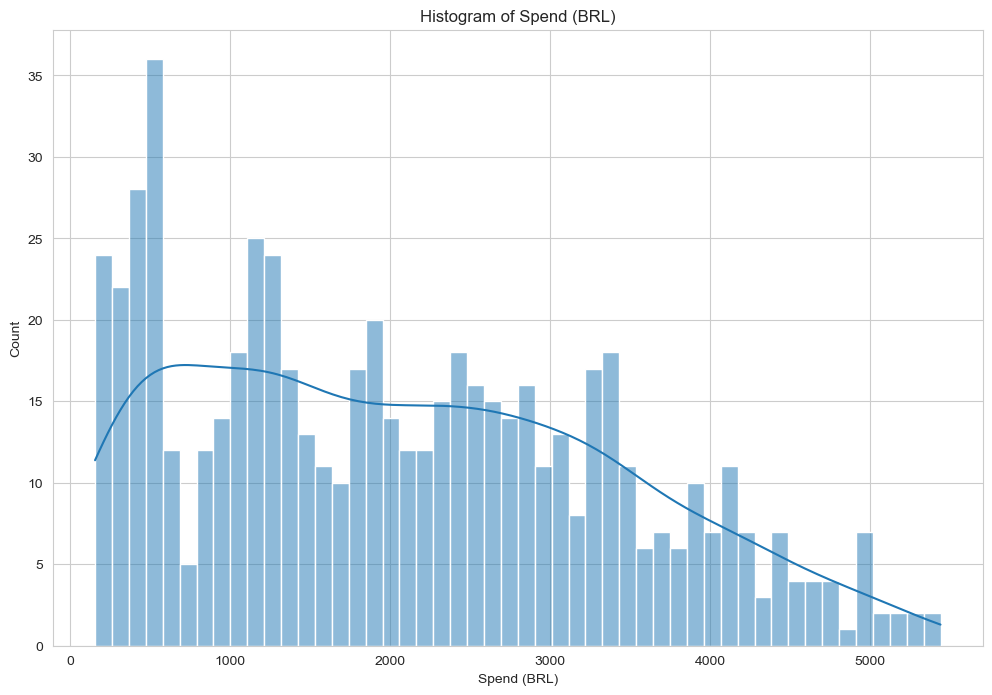

In [10]:
plt.figure(figsize=(12,8))
sns.histplot(data=df, x="Spend (BRL)", bins=50, kde=True)
plt.title("Histogram of Spend (BRL)")
plt.xlabel("Spend (BRL)")
plt.ylabel("Count")
plt.savefig("picture/sanity_check/histogram_spend.png", dpi=300, bbox_inches='tight')
plt.show()

Boxplot of Impressions

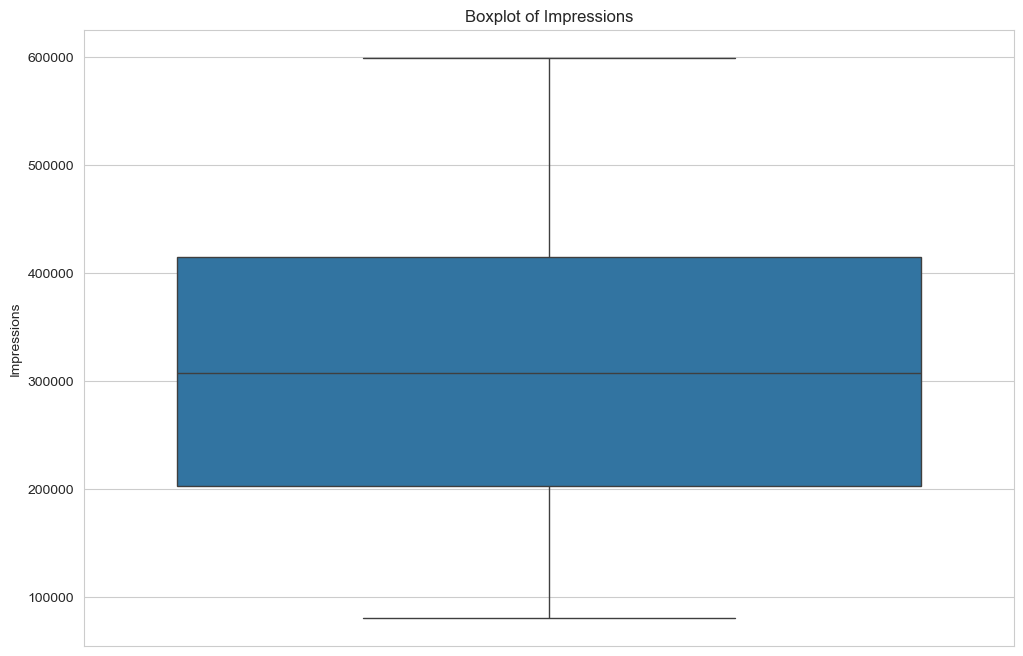

In [11]:
plt.figure(figsize=(12,8))
sns.boxplot(data=df, y="Impressions")
plt.title("Boxplot of Impressions")
plt.ylabel("Impressions")
plt.savefig("picture/sanity_check/boxplot_impression.png", dpi=300, bbox_inches='tight')
plt.show()

Bar chart of Delivery status

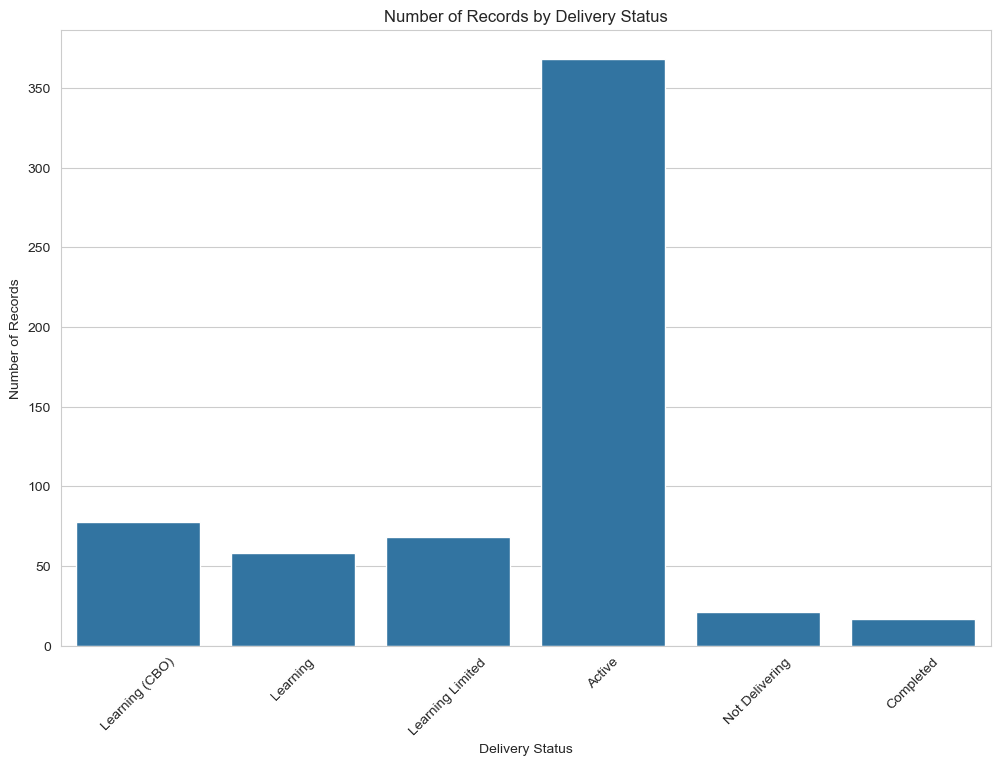

In [12]:
plt.figure(figsize=(12,8))
sns.countplot(data=df, x="Delivery")
plt.title("Number of Records by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Records")
plt.xticks(rotation=45) 
plt.savefig("picture/sanity_check/countplot_delivery.png", dpi=300, bbox_inches='tight')  # caso os nomes sejam longos
plt.show()

Bar chart of Attribution Setting

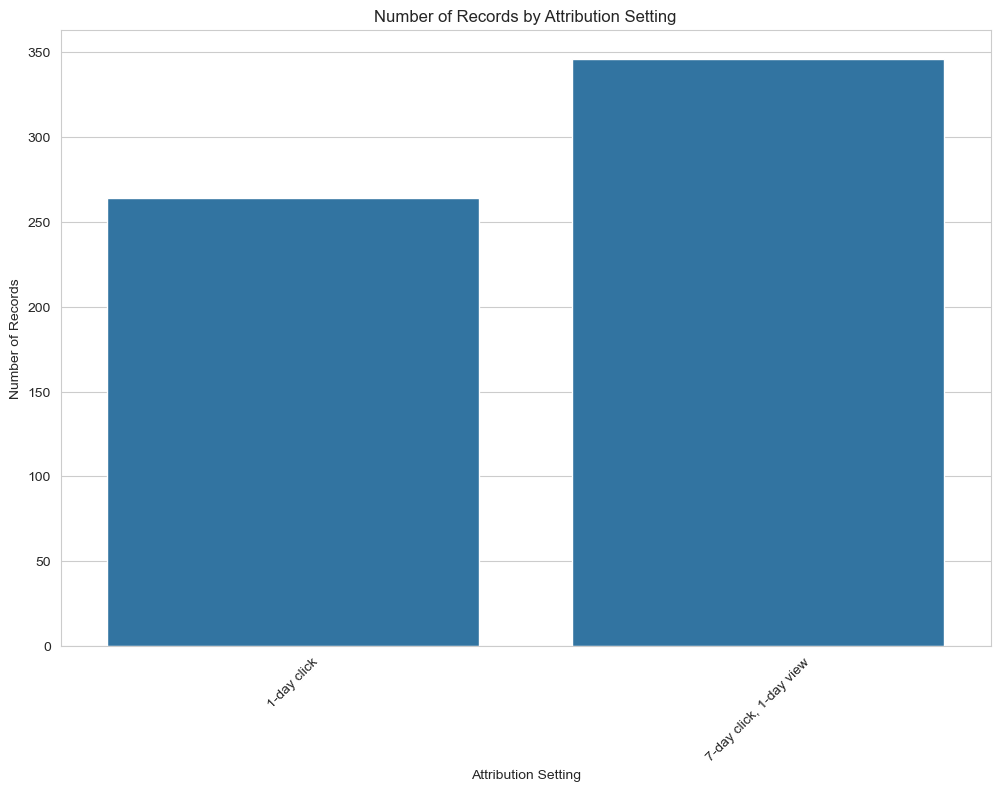

In [13]:
plt.figure(figsize=(12,8))
sns.countplot(data=df, x="Attribution Setting")
plt.title("Number of Records by Attribution Setting")
plt.xlabel("Attribution Setting")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.savefig("picture/sanity_check/countplot_attribution.png", dpi=300, bbox_inches='tight')
plt.show()

Save plots

In [14]:
# TODO: Join this code with the EDA on the stringlit app